In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [2]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

ROOT = Path("../sample_datasets/20221031_AmBe/")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

psd = pd.read_csv(PSD_PATH, header=None)
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]
psd_report = psd_report.dropna(axis=0)
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]

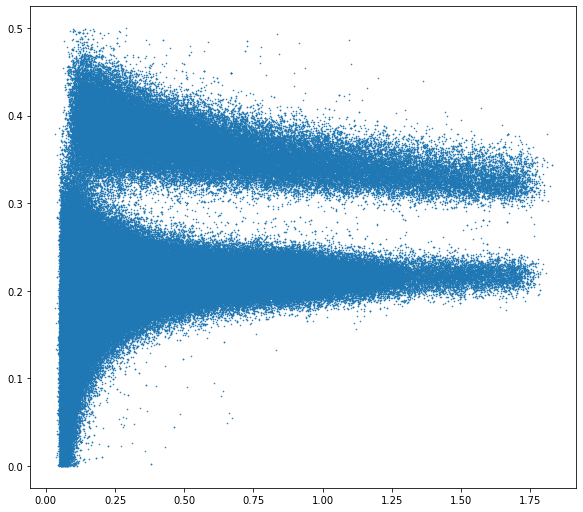

In [3]:
# Plot PSD
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
# ax.set_ylim(-0.5,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

# Converting Voltage to Light Output

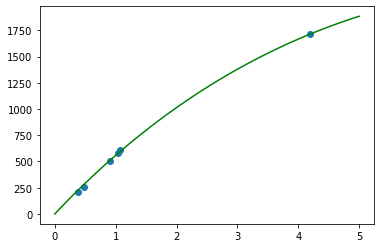

In [4]:
# plt.plot(np.linspace(0,5,50), exponential(np.linspace(0,5,50), *cali_params))

cal_x = np.array([0.4758, 1.0406, 0.9033, 0.3755, 1.0670, 4.1984])
cal_y = np.array([256.5, 581.87, 509.15, 206.8, 608.77, 1714.9])

def exponential(x, a, b, c, d):
    return a*np.exp(b*x) + c*np.exp(d*x)

def logarithmic(x, a, b, c):
    return a*np.log(b*x+1)+c*x


l_params, cov = curve_fit(
    logarithmic,
    cal_x,
    cal_y,
    bounds=((0, -20, -3e4),(20e3, 20, 3e3))
)

f_cal = np.poly1d(np.polyfit(cal_x, cal_y, 2))




xspace = np.linspace(0,5,50)
# plt.plot(xspace, f_cal(xspace) ,'r')
plt.plot(xspace, logarithmic(xspace,*l_params) ,'g')
plt.scatter(cal_x, cal_y)
# plt.ylim(0, 2000)
# plt.xlim(0.75,1.25)

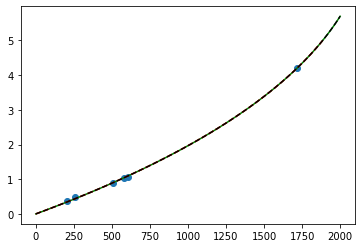

In [5]:
from pynverse import inversefunc

plt.scatter(cal_y, cal_x)
yspace = np.linspace(0,2000,100)
inv_vals = inversefunc(lambda x: logarithmic(x, *l_params), y_values=yspace)
f_l = np.poly1d(np.polyfit(yspace, inv_vals, 9))

plt.plot(yspace, inv_vals ,'g')
plt.plot(logarithmic(xspace,*l_params), xspace ,'r--')
plt.plot(yspace, f_l(yspace) ,'k--')

In [6]:
# def v_to_l(voltage):
#     V1 = 205 * 1e-3
#     L1 = 900 * 1e-3
#     V2 = 290 * 1e-3
#     L2 = 1200 * 1e-3

#     m = (L2-L1) / (V2-V1)
#     b =  L1 - m * V1
#     return m * voltage + b

def v_to_l(voltage):
    return f_l(voltage)

psd_report["energy"] = (psd_report["amplitude"] * 1e3).apply(v_to_l)

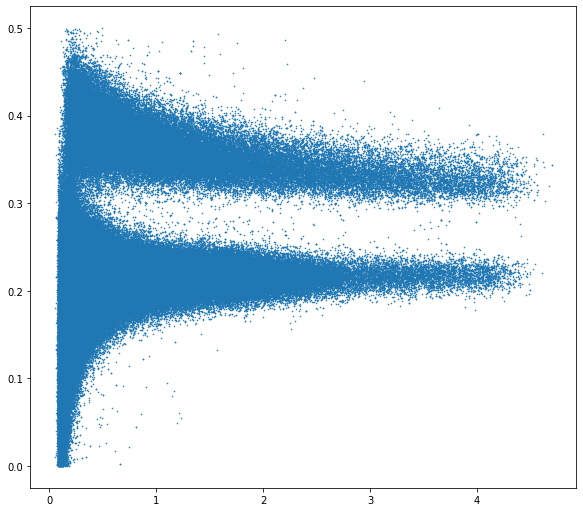

In [7]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
# ax.set_ylim(0,0.5)

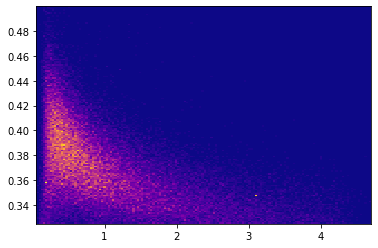

In [8]:
neutron_psd = psd_report[psd_report["tail / total"].between(0.325, 0.5)]
x, y = neutron_psd["energy"], neutron_psd["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 150)
L4_e = xe[-2]
cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
# plt.ylim(0,0.45)

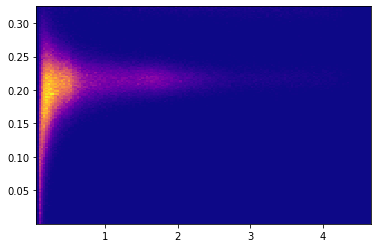

In [9]:
gamma_psd = psd_report[psd_report["tail / total"].between(0, 0.325)]
x, y = gamma_psd["energy"], gamma_psd["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 150)
L4_e = xe[-2]
cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
# plt.ylim(0,0.45)

In [18]:
def sigma_slice(ye, counts, idx, lb, ub):
    return curve_fit(
        gaussian,
        ye[:-1], 
        counts[:,idx],
        bounds=(lb,ub)
    )


def get_gamma_bound_point(xe, ye, counts, idx, lb, ub):
    energy = (xe[idx] + xe[idx + 1]) / 2
    (mu, sigma, A), cov = sigma_slice(ye, counts, idx, lb, ub)
    
    return energy, mu, sigma
    

    
min_i = 4

n_counts = Z.T
n_energy = []
n_sigma = []
n_mu = []
for idx in range(min_i, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, n_counts, idx, lb=(0.325,0.001,1), ub=(0.38,0.2,10_000))
    n_energy.append(e)
    n_sigma.append(s)
    n_mu.append(m)
    
    
g_counts = Z.T
g_energy = []
g_sigma = []
g_mu = []
for idx in range(min_i, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, g_counts, idx, lb=(0.1,0.001,1), ub=(0.3,0.5,10_000))
    g_energy.append(e)
    g_sigma.append(s)
    g_mu.append(m)

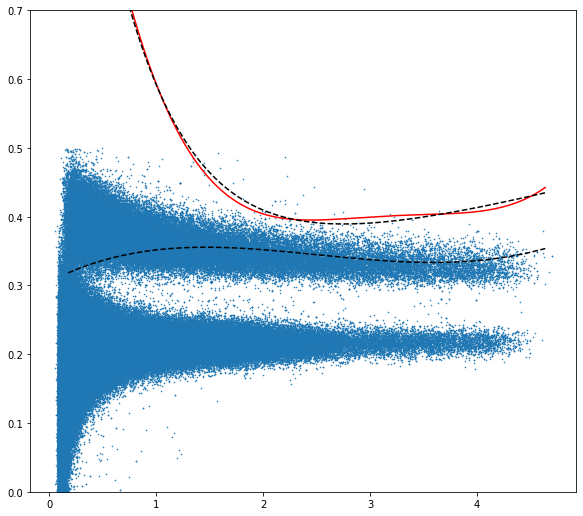

In [19]:
poly_n = 4

def exp(x, a, b, c, d):
    return a*np.exp(b*x) + c*np.exp(d*x)


fn_sigma = np.poly1d(np.polyfit(xe[min_i:-1], n_sigma, poly_n))
fn_mu = np.poly1d(np.polyfit(xe[min_i:-1], n_mu, poly_n))

params, cov = curve_fit(exp, xe[min_i:-1], fn_mu(xe[min_i:-1]) + 4 * fn_sigma(xe[min_i:-1]))

# fg_sigma = np.poly1d(np.polyfit(xe[min_i:-1], g_sigma, poly_n))
# fg_mu = np.poly1d(np.polyfit(xe[min_i:-1], g_mu, poly_n))

fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.7)

# offset = np.average(fn_mu(xe[min_i:-1]) - fg_mu(xe[min_i:-1]))

ax.plot(xe[min_i:-1], fn_mu(xe[min_i:-1]), 'k--')
ax.plot(xe[min_i:-1], fn_mu(xe[min_i:-1]) + 4 * fn_sigma(xe[min_i:-1]), 'r')
ax.plot(xe[min_i:-1], exp(xe[min_i:-1], *params), 'k--')
# ax.plot(xe[min_i:-1], fn_mu(xe[min_i:-1]) - 3 * fn_sigma(xe[min_i:-1]), 'r')



# ax.plot(xe[min_i:-1], fg_mu(xe[min_i:-1]), 'k--')
# ax.plot(xe[min_i:-1], fg_mu(xe[min_i:-1]) + 4 * fg_sigma(xe[min_i:-1]), 'r')
# ax.plot(xe[min_i:-1], fg_mu(xe[min_i:-1]) + 4 * fg_sigma(xe[min_i:-1]) + offset, 'r')
# ax.plot(xe[min_i:-1], fg_mu(xe[min_i:-1]) - 4 * fg_sigma(xe[min_i:-1]), 'r')

# ax.plot(xe[min_i:-1], fg_mu(xe[min_i:-1]) + 4 * fg_sigma(xe[min_i:-1]), 'r')

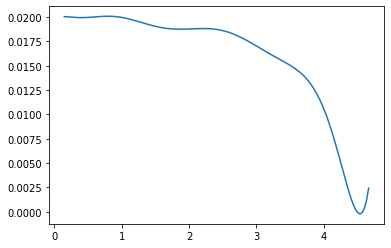

In [50]:
xe_r = np.linspace(0, xe[-1], 200)
# plt.plot(xe[3:-1], lower_bound, 'r-')
plt.plot(xe[min_i:-1], f_sigma())

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



In [143]:
def lo_output(Ep):
    return 0.748*Ep-2.41*(1-np.exp(-0.298*Ep))

L1, L2, L3 = lo_output(np.array([2.5, 4.0, 6.0]))

cutoffs = [L1, L2, L3]

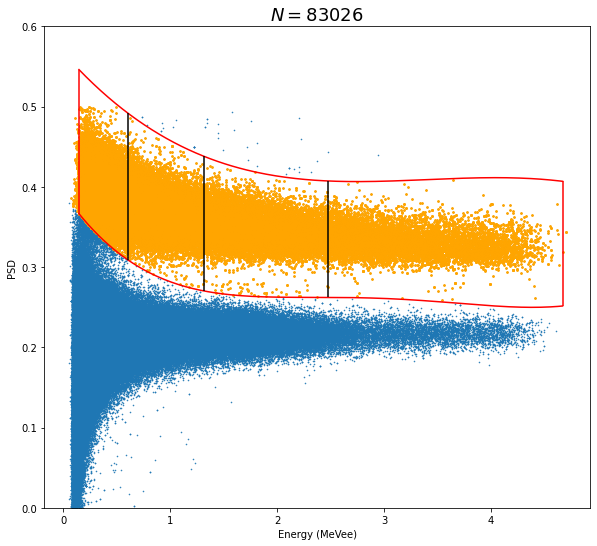

In [144]:
def f_lb(energy):
    return fg_mu(energy) + 4 * fg_sigma(energy)

def f_ub(energy):
    return fn_mu(energy) + 4 * fn_sigma(energy)


neutrons = psd_report[psd_report["tail / total"].between(f_lb(psd_report["energy"]), f_ub(psd_report["energy"]))]

# plot distribution
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.6)

xe_r = np.linspace(xe[min_i], xe[-1], 200)

# plot bounds
ax.plot(xe_r, f_ub(xe_r), 'r-')
ax.plot(xe_r, f_lb(xe_r), 'r-')

# plot vlines
ax.vlines(xe_r[0], f_lb(xe_r[0]), f_ub(xe_r[0]) ,'r')
ax.vlines(xe_r[-1], f_lb(xe_r[-1]), f_ub(xe_r[-1]), 'r')

# plot neutrons
ax.scatter(neutrons["energy"], neutrons["tail / total"], marker="o", s=3, c="orange")

ax.set_title(f"$N={neutrons.shape[0]}$", fontsize=18)
ax.set_ylabel("PSD")
ax.set_xlabel("Energy (MeVee)")

for lo in cutoffs:
    ax.vlines(lo, f_lb(lo), f_ub(lo), 'k')
    

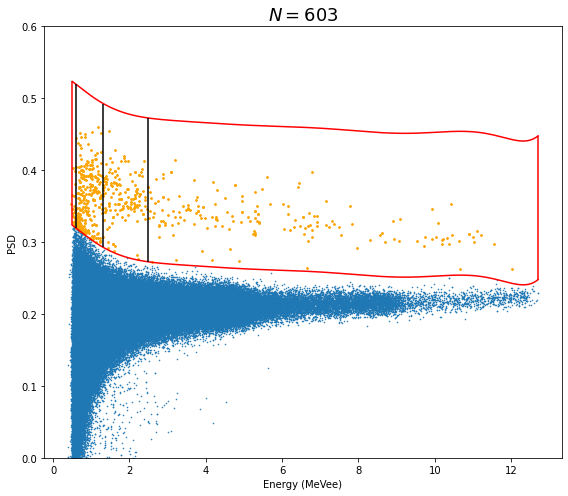

In [13]:
fig, ax, neutrons = classify_plot(psd_report, xe, f_lb)
fig.tight_layout()

# Altogether

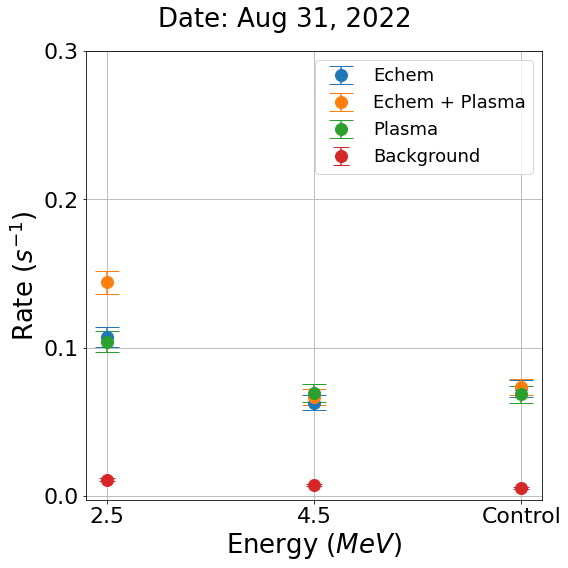

In [65]:
bins = ["2.5", "4.5", "Control"]

fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar(bins, rates_e, yerr=sigmas_e, fmt = "o", markersize=12, linestyle="", label="Echem", capsize=12)
ax.errorbar(bins, rates_ep, yerr=sigmas_ep, fmt = "o", markersize=12, linestyle="", label="Echem + Plasma", capsize=12)
ax.errorbar(bins, rates_p, yerr=sigmas_p, fmt = "o", markersize=12, linestyle="", label="Plasma", capsize=12)
ax.errorbar(bins, rates_bg, yerr=sigmas_bg, fmt = "o", markersize=12, linestyle="", label="Background", capsize=8)

ax.set_ylabel("Rate $(s^{{-1}})$", fontsize=26)
ax.set_xlabel("Energy $(MeV)$", fontsize=26)
# ax.set_ylim(0.0, 0.3)
ax.set_yticks(np.arange(0,0.4,0.1))
fig.suptitle("Date: Aug 31, 2022", fontsize=26)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
ax.grid()
ax.legend(fontsize=18)
fig.tight_layout()
plt.show()